# **Extended Data Figure 8**
Reproduces Extended Data Figure 8 from simulation data. Data used (full MANC simulations, 32 replicates each for total 128 replicates):
- `DNg100_Stim_fullManc/hyak/run_id=30662613`(**b**)
- `DNg100_Stim_fullManc/hyak/run_id=33195857`(**b**)
- `DNg100_Stim_fullManc/hyak/run_id=33195876`(**b**)
- `DNg100_Stim_fullManc/hyak/run_id=33195882`(**b**)

In [ ]:
dataPath = "/data/users/smpuglie/published-simulations/"

In [1]:
## imports
import matplotlib.pyplot as plt
from src.utils.plot_utils import *
from src.utils.sim_utils import *
import yaml
import numpy as np
import jax.numpy as jnp
import sparse
from hydra import initialize, compose
from hydra.core.hydra_config import HydraConfig
from omegaconf import DictConfig, OmegaConf
from pathlib import Path, PosixPath
from datetime import date

## plotting defaults
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["axes.spines.right"] = "False"
plt.rcParams["axes.spines.top"] = "False"
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["figure.figsize"] = (2,2)
plt.rcParams['axes.linewidth'] = 0.25
plt.rcParams["xtick.major.size"] = 1.7
plt.rcParams["ytick.major.size"] = 1.7
plt.rcParams["xtick.major.width"] = 0.25
plt.rcParams["ytick.major.width"] = 0.25
plt.rcParams["figure.dpi"] = 200

SMALL_SIZE = 6
LABEL_SIZE = 7
AXLABEL_SIZE = 8
TITLE_SIZE = 10

plt.rcParams["font.family"] = "Arial" # "Arial"
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=TITLE_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=AXLABEL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=LABEL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=TITLE_SIZE)  # fontsize of the figure title

plt.rcParams["axes.labelpad"] = 1.5
plt.rcParams["xtick.major.pad"] = 1.5
plt.rcParams["ytick.major.pad"] = 1.5

moduleColors = get_module_colors()

dnColor = "#51bbad"
excColor = "#d84a2e"
inhColor = "#026b85"
mnColor = "#267655"

lightDnColor = "#a7dcd5ff"
lightExcColor = "#ff9985"
lightInhColor = "#00acd6"
connColormap = sns.blend_palette([inhColor,lightInhColor,"white",lightExcColor,excColor],as_cmap=True)

Using diffeqsolve-based neural simulation (original)


# Connectivity plots: DNg100-E1-E2-I1-I2 in all 6 legs (MANC)

In [ ]:
wTable = feather.read_feather("../data/manc full vnc data/wTable_20251006.feather")
W = feather.read_feather("../data/manc full vnc data/W_20251006.feather").to_numpy().astype(float)

figFolder = "../figures/minicircuit-plots-"+date.today().strftime("%Y%m%d")

In [4]:
# miniTypes = ["DNg100","IN17A001","INXXX466","IN19B012","IN03A006","INXXX464","IN16B036","IN19A007"]
miniTypes = ["DNg100","IN17A001","INXXX466","IN16B036","IN19A007"]
miniTypesToLabels = {"DNg100": "DNg100",
                     "IN17A001": "E1 (IN17A001)",
                     "INXXX466": "E2 (INXXX466)",
                     "IN16B036": "I1 (IN16B036)",
                     "IN19A007": "I2 (IN19A007)"}

mnData = sort_motor_modules(wTable.loc[(wTable["class"]=="motor neuron") & (wTable["subclass"].isin(["fl","ml","hl"]))])

miniData = wTable.loc[wTable["type"].isin(miniTypes)]
miniData["ticklabel"] = miniData["type"].map(miniTypesToLabels)
miniData = pd.concat([miniData,mnData])
miniData["circuitSide"] = miniData["somaSide"]
miniData["circuitSide"].loc[(miniData["subclass"]=="BR")&(miniData["somaSide"]=="LHS")] = "RHS"
miniData["circuitSide"].loc[(miniData["subclass"]=="BR")&(miniData["somaSide"]=="RHS")] = "LHS"

/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",
/tmp/ipykernel_49113/3458523055.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  miniData["ticklabel"] = miniData["type"].map(miniTypesToLabels)
/tmp/ipykernel_49113/3458523055.py:15: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You ar

/tmp/ipykernel_49113/353508126.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  legMiniData["type"] = pd.Categorical(legMiniData["type"],categories=miniTypes+mnData["type"].unique().tolist())
/tmp/ipykernel_49113/353508126.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  legMiniData.sort_values("type",inplace=True)
/tmp/ipykernel_49113/353508126.py:17: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  modules = mnData["motor module"].unique().dropna().to_list()


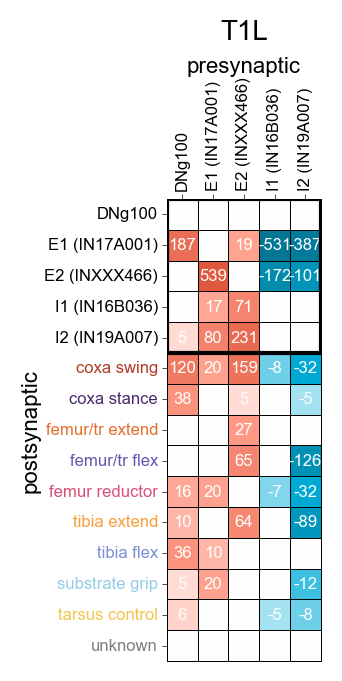

/tmp/ipykernel_49113/353508126.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  legMiniData["type"] = pd.Categorical(legMiniData["type"],categories=miniTypes+mnData["type"].unique().tolist())
/tmp/ipykernel_49113/353508126.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  legMiniData.sort_values("type",inplace=True)
/tmp/ipykernel_49113/353508126.py:17: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  modules = mnData["motor module"].unique().dropna().to_list()


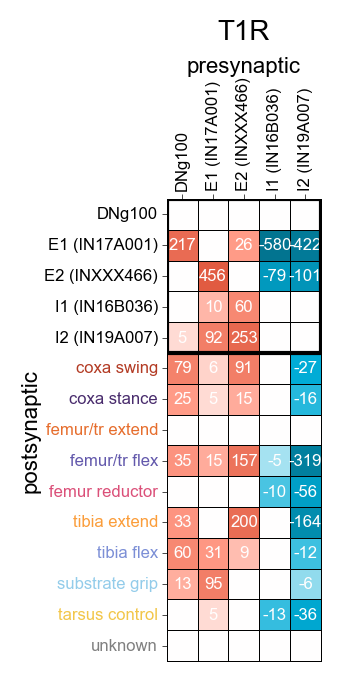

/tmp/ipykernel_49113/353508126.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  legMiniData["type"] = pd.Categorical(legMiniData["type"],categories=miniTypes+mnData["type"].unique().tolist())
/tmp/ipykernel_49113/353508126.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  legMiniData.sort_values("type",inplace=True)
/tmp/ipykernel_49113/353508126.py:17: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  modules = mnData["motor module"].unique().dropna().to_list()


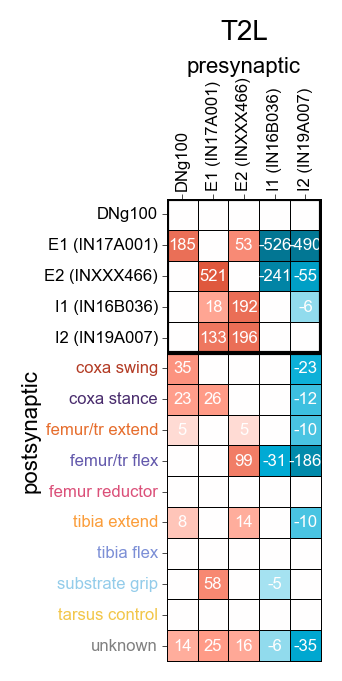

/tmp/ipykernel_49113/353508126.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  legMiniData["type"] = pd.Categorical(legMiniData["type"],categories=miniTypes+mnData["type"].unique().tolist())
/tmp/ipykernel_49113/353508126.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  legMiniData.sort_values("type",inplace=True)
/tmp/ipykernel_49113/353508126.py:17: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  modules = mnData["motor module"].unique().dropna().to_list()


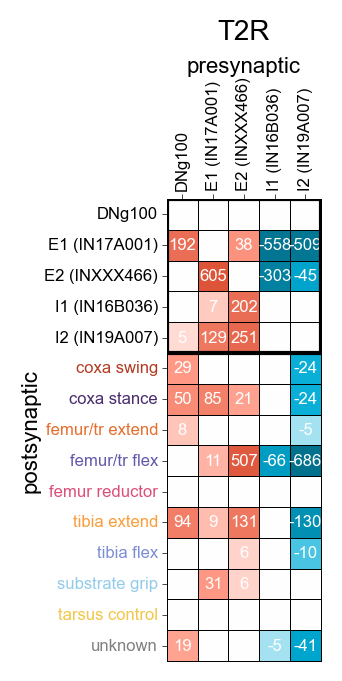

/tmp/ipykernel_49113/353508126.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  legMiniData["type"] = pd.Categorical(legMiniData["type"],categories=miniTypes+mnData["type"].unique().tolist())
/tmp/ipykernel_49113/353508126.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  legMiniData.sort_values("type",inplace=True)
/tmp/ipykernel_49113/353508126.py:17: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  modules = mnData["motor module"].unique().dropna().to_list()


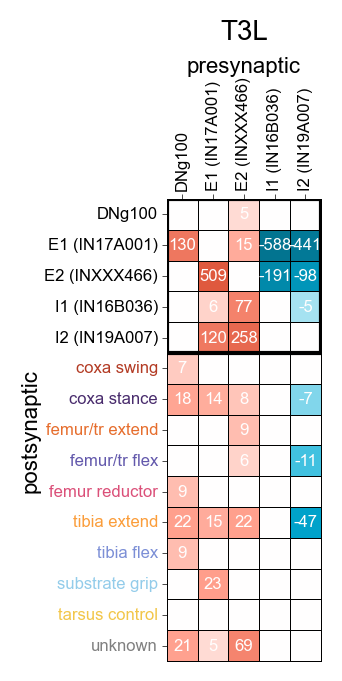

/tmp/ipykernel_49113/353508126.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  legMiniData["type"] = pd.Categorical(legMiniData["type"],categories=miniTypes+mnData["type"].unique().tolist())
/tmp/ipykernel_49113/353508126.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  legMiniData.sort_values("type",inplace=True)
/tmp/ipykernel_49113/353508126.py:17: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  modules = mnData["motor module"].unique().dropna().to_list()


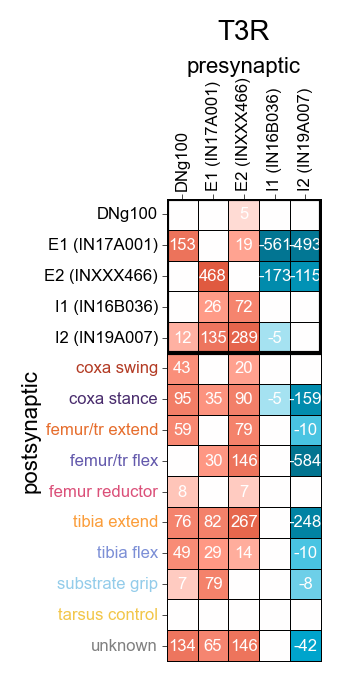

In [5]:
nIns = 5

for neuromere in ["T1","T2","T3"]:
    for side in ["LHS","RHS"]:      

        fig = plt.figure()
        legMiniData = miniData.loc[((miniData["circuitSide"]==side) & (miniData["somaNeuromere"]==neuromere)) |
                                    (miniData["rootSide"]==side)]

        legMiniData["type"] = pd.Categorical(legMiniData["type"],categories=miniTypes+mnData["type"].unique().tolist())
        legMiniData.sort_values("type",inplace=True)
        miniW = W[np.ix_(legMiniData.index,legMiniData.index)]

        moduleGroupedW = miniW[:nIns,:nIns]
        annot = True

        modules = mnData["motor module"].unique().dropna().to_list()
        for mod in modules:
            weightsToMod = np.sum(W[legMiniData.index[:nIns]][:,legMiniData.loc[legMiniData["motor module"]==mod].index],axis=1)
            moduleGroupedW = np.append(moduleGroupedW,np.expand_dims(weightsToMod,axis=1),axis=1)

        weightsToUnknown = np.sum(W[legMiniData.index[:nIns]][:,legMiniData.loc[(legMiniData["class"]=="motor neuron") & (legMiniData["motor module"].isna())].index],axis=1)
        moduleGroupedW = np.append(moduleGroupedW,np.expand_dims(weightsToUnknown,axis=1),axis=1)
        modules += ["unknown"]

        # moduleGroupedW = np.append(moduleGroupedW,np.zeros((9,13)),axis=0)

        ax = sns.heatmap(moduleGroupedW.T,norm = colors.SymLogNorm(10,vmin=-1000,vmax=1000),
                    cmap=connColormap,square=True,
                    xticklabels=legMiniData["ticklabel"].iloc[:nIns],yticklabels=legMiniData["ticklabel"].iloc[:nIns].tolist()+modules,
                    linewidths=0.25, linecolor='black',
                    annot=annot,fmt=".0f",clip_on=False,cbar=False,annot_kws={"fontsize":6,"color":connColormap(0.5)})

        moduleColors = get_module_colors()
        moduleColors["unknown"] = "#808080"
        for i in range(len(ax.get_yticklabels())):
            label = ax.get_yticklabels()[i]
            try:
                label.set_color(moduleColors[label.get_text()])
            except:
                label.set_color("#000000")

        plt.vlines([0,nIns],0,nIns,colors="k",linewidth=1.5,zorder=10)
        plt.hlines([0,nIns],0,nIns,colors="k",linewidth=1.5,zorder=10)
        fig = plt.gcf()
        ax.tick_params("x",labelrotation=90)
        ax.tick_params("y",labelrotation=0)
        plt.xlabel("presynaptic")
        plt.ylabel("postsynaptic")
        plt.title(neuromere + side[0],fontsize=10)
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top') 
        if annot:
            fig.set_figheight(3)
            fig.set_figwidth(3)
        # plt.tight_layout()
        plt.subplots_adjust(right=1.2)
        
        # if not os.path.exists(figFolder):
        #     os.makedirs(figFolder)
        # plt.savefig(figFolder+f"/manc_modules_{neuromere}{side[0]}.svg",transparent=True)
        plt.show()

# Full MANC data E1 phase offsets

In [6]:
from scipy import signal

def wave_normalize(x):
    return x/np.mean(x)

def estimate_period_autocorr(x):
    norm_x = x - x.mean() # should be redundant but yaknow
    autocorr = np.correlate(norm_x, norm_x, mode='full')
    autocorr = autocorr[len(autocorr)//2:]  # keep positive lags only
    # Find the first prominent peak after lag 0
    peaks, _ = signal.find_peaks(autocorr, prominence=0.05)
    return peaks[0] if len(peaks) > 0 else np.nan

In [ ]:
simType = "DNg100_Stim_fullManc"
runIds = ["30662613","33195857","33195876","33195882"]

simPath = simType+"/hyak/30662613-33195857-33195876-33195882"
folder = dataPath + simPath
Rs = sparse.load_npz(folder+f"/{simType}_Rs.npz").todense()
params = DictConfig(load_from_yaml(dataPath+simType+"/hyak/run_id=30662613/logs/run_config.yaml")) # garbage...
wTable = load_wTable("../"+params.experiment["dfPath"].split("vnc-connectome-sim")[1])

nSims = Rs.shape[0]
Rs.shape

(128, 23532, 2001)

,bodyId,type,instance,class,subclass,hemilineage,size,predictedNt,predictedNtProb,somaSide,somaNeuromere,rootSide,motor module,step contribution
621,10707,IN17A001,IN17A001_T1_L,intrinsic neuron,IR,17A,3939072421,acetylcholine,0.915736,LHS,T1,None,,
607,10690,IN17A001,IN17A001_T1_R,intrinsic neuron,IR,17A,4468840770,acetylcholine,0.889646,RHS,T1,None,,
486,10559,IN17A001,IN17A001_T2_L,intrinsic neuron,IR,17A,4135808976,acetylcholine,0.918169,LHS,T2,None,,
44,10072,IN17A001,IN17A001_T2_R,intrinsic neuron,IR,17A,3996838657,acetylcholine,0.933696,RHS,T2,None,,
429,10498,IN17A001,IN17A001_T3_L,intrinsic neuron,IR,17A,3977308214,acetylcholine,0.948191,LHS,T3,None,,
485,10558,IN17A001,IN17A001_T3_R,intrinsic neuron,IR,17A,3949026249,acetylcholine,0.934298,RHS,T3,None,,


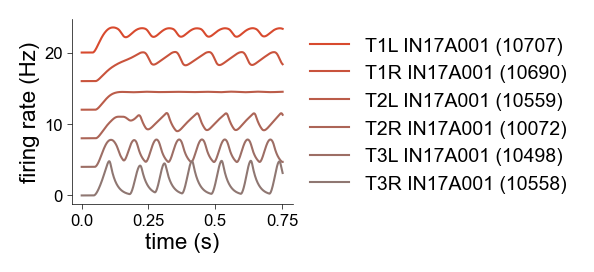

In [8]:
e1Data = wTable.loc[wTable["type"].eq("IN17A001")].sort_values(["somaNeuromere","somaSide"])
e1Idxs = e1Data.index.to_numpy()
display(e1Data)

idx = 3
R = Rs[idx]
spacer = 4
fig = plt.figure()
ax = plot_R_traces_stacked_2(R[:,:750],e1Data,activeOnly=True,cmap=sns.blend_palette([excColor,"gray"],as_cmap=True),space=spacer)
add_tAxis(ax,0.75,3.0001)

plt.ylabel("firing rate (Hz)")
plt.xlabel("time (s)")

fig.set_dpi(200)
fig.set_figwidth(1.426)
fig.set_figheight(1.2)

plt.show()

In [9]:
start = 250

e1PhaseOffsets = np.full((nSims,6,6),fill_value=np.nan)
e1MaxCorrCoefs = np.full((nSims,6,6),fill_value=np.nan)
e1Periods = np.full((nSims,6),fill_value=np.nan)
e1PeriodDifferences = np.full((nSims,6,6),fill_value=np.nan)

e1ShufflePhaseOffsets = np.full((nSims,6,6),fill_value=np.nan)

shuffleSimIdxs = np.arange(nSims)
np.random.default_rng(seed=86572).shuffle(shuffleSimIdxs)

for simIdx in range(nSims):
    e1Activity = Rs[simIdx][e1Idxs][:,start:]

    shuffleSimIdx = shuffleSimIdxs[simIdx]
    shuffleActivity = Rs[shuffleSimIdx][e1Idxs][:,start:]
    for i in range(6):
        for j in range(6):
            x1 = e1Activity[i]
            x2 = e1Activity[j]

            # normalize
            x1 = (x1-np.mean(x1))/np.std(x1)
            x2 = (x2-np.mean(x2))/np.std(x2)
            x1_period = estimate_period_autocorr(x1)
            x2_period = estimate_period_autocorr(x2)
            if np.isnan(x1_period):
                continue
            
            xcorr = np.correlate(x1, x2, mode='full')

            maxOffset = x1_period  # only search within one period
            center = len(x1) - 1
            xcorr_windowed = xcorr[center - maxOffset : center + maxOffset]
            offset = np.argmax(xcorr_windowed) - maxOffset
            # offset = np.argmax(xcorr) - (len(x1) - 1)
            phaseOffset = offset/x1_period * 2*np.pi
            phaseOffset = (phaseOffset + np.pi) % (2 * np.pi) - np.pi # correct for angle wraparound    
            maxCorrCoef = np.max(xcorr) / len(x1)

            e1PhaseOffsets[simIdx][i][j] = phaseOffset
            e1MaxCorrCoefs[simIdx][i][j] = maxCorrCoef
            e1Periods[simIdx][i] = x1_period*params.sim.dt
            e1PeriodDifferences[i][j] = (x1_period-x2_period)*params.sim.dt

            # control
            x2shuffle = shuffleActivity[j]
            x2shuffle = (x2shuffle-np.mean(x2shuffle))/np.std(x2shuffle)
            x2shuffle_period = estimate_period_autocorr(x2shuffle)

            xcorrShuffle = np.correlate(x1, x2shuffle, mode='full')

            xcorrShuffle_windowed = xcorrShuffle[center - maxOffset : center + maxOffset]
            shuffleOffset = np.argmax(xcorrShuffle_windowed) - maxOffset
            # shuffleOffset = np.argmax(xcorrShuffle) - (len(x1) - 1)
            shufflePhaseOffset = shuffleOffset/x1_period * 2*np.pi
            shufflePhaseOffset = (shufflePhaseOffset + np.pi) % (2 * np.pi) - np.pi # correct for angle wraparound    

            e1ShufflePhaseOffsets[simIdx][i][j] = shufflePhaseOffset

        
figFolder = "../figures/"
figFolder += "-".join([simType]+runIds)

/tmp/ipykernel_49113/799840586.py:49: RuntimeWarning: invalid value encountered in divide
  x2shuffle = (x2shuffle-np.mean(x2shuffle))/np.std(x2shuffle)
/tmp/ipykernel_49113/799840586.py:24: RuntimeWarning: invalid value encountered in divide
  x1 = (x1-np.mean(x1))/np.std(x1)
/tmp/ipykernel_49113/799840586.py:25: RuntimeWarning: invalid value encountered in divide
  x2 = (x2-np.mean(x2))/np.std(x2)


/tmp/ipykernel_49113/442347570.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(e1PhaseOffsets[:,i,j],clip=[-np.pi,np.pi],color=excColor,ax=axes[i][j],fill=True,linewidth=0, alpha=1)
/tmp/ipykernel_49113/442347570.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(e1PhaseOffsets[:,i,j],clip=[-np.pi,np.pi],color=excColor,ax=axes[i][j],fill=True,linewidth=0, alpha=1)
/tmp/ipykernel_49113/442347570.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(e1PhaseOffsets[:,i,j],clip=[-np.pi,np.pi],color=excColor,ax=axes[i][j],fill=True,linewidth=0, alpha=1)
/tmp/ipykernel_49113/442347570.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(e1PhaseOffsets[:,i,j],c

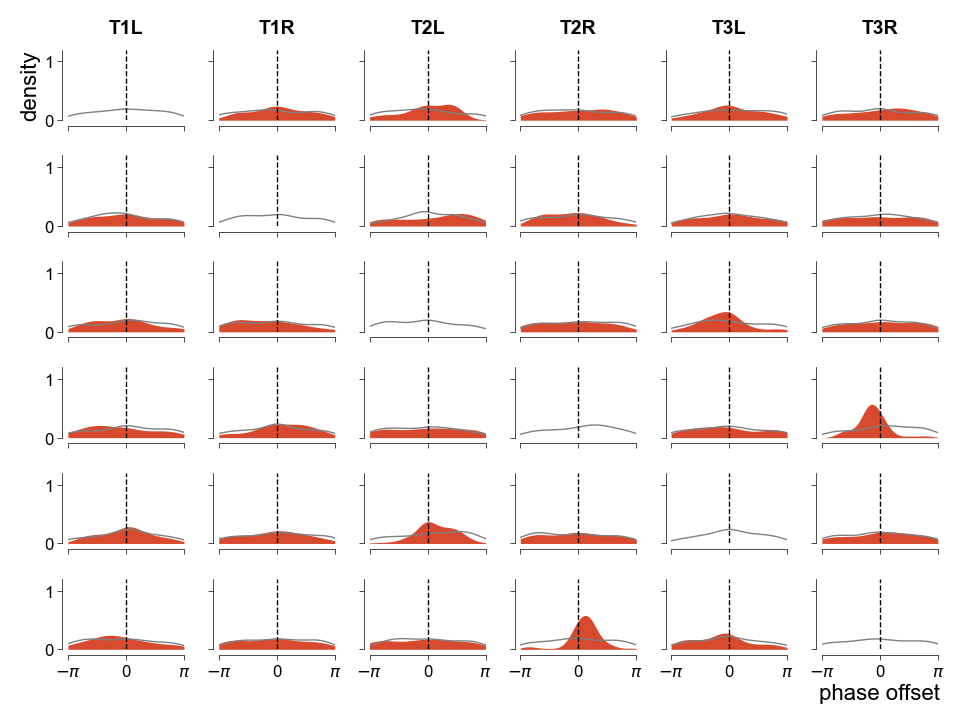

In [ ]:
fig, axes = plt.subplots(6,6,sharex=True,sharey=True)
for i in range(6):
    for j in range(6):
        if i == 0:
            axes[i][j].set_title(f'{e1Data["somaNeuromere"].iloc[j]}{e1Data["somaSide"].iloc[j][0]}',fontweight="bold",fontsize=7)
        sns.kdeplot(e1PhaseOffsets[:,i,j],clip=[-np.pi,np.pi],color=excColor,ax=axes[i][j],fill=True,linewidth=0, alpha=1)
        sns.kdeplot(e1ShufflePhaseOffsets[:,i,j],clip=[-np.pi,np.pi],color="gray",ax=axes[i][j],fill=False,linewidth=0.5,)
        axes[i][j].axvline(linestyle="--",color="k",linewidth=0.5,)
        axes[i][j].set_ylabel("")
        axes[i][j].set_xticks(np.linspace(-np.pi,np.pi+0.0001,3),[r"$-\pi$","0",r"$\pi$"],fontsize=4.5)
        plt.xlabel("phase offset")

        axes[i][j].set_xlim(-np.pi,np.pi+0.0001)

sns.despine(offset=2)

axes[0][0].set_ylabel("density")

plt.ylim([0,1.2])
fig.set_figheight(3.6)
fig.set_figwidth(4.8)
plt.tight_layout()
plt.subplots_adjust(hspace=0.5,wspace=0.3)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/e1PhaseOffsets_kde_larger_wNull.svg",transparent=True)
plt.show()